In [58]:
import pandas as pd

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import nltk
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from tqdm.auto import tqdm
from nltk.tokenize import word_tokenize
import string
import os
import sys
from contextlib import contextmanager
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
import matplotlib.pyplot as plt
import seaborn as sns
import spacy


In [19]:
df = pd.read_csv(r"C:\Users\Kirill\Desktop\jupyter_projects\datasets_jupyter\combined_data.csv")
df["text"] = df["text"].astype(str)

In [26]:
def doc_to_vec(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)


In [20]:
@contextmanager
def suppress_stderr():
    """Временно перенаправляет stderr в /dev/null"""
    old_stderr = sys.stderr
    try:
        sys.stderr = open(os.devnull, "w")
        yield
    finally:
        sys.stderr.close()
        sys.stderr = old_stderr


# NLTK без пунктуации

In [21]:
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
stop = set(stopwords.words('english'))

In [22]:
tokenized_nltk_no_punct = []
for text in tqdm(df["text"], desc="NLTK tokenizing (no punct)"):
    tokens = word_tokenize(text.lower())
    # Убираем пунктуацию и стоп-слова
    tokens = [w for w in tokens if w not in string.punctuation and w not in stop and len(w) > 2]
    tokenized_nltk_no_punct.append(tokens)


NLTK tokenizing (no punct): 100%|██████████| 83448/83448 [01:56<00:00, 714.73it/s] 


In [23]:
mask = [len(x) > 0 for x in tokenized_nltk_no_punct]
X_nltk_no_p = [x for i, x in enumerate(tokenized_nltk_no_punct) if mask[i]]
y_nltk = df["label"].values[mask]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_nltk_no_p, y_nltk, test_size=0.2, random_state=42, stratify=y_nltk
)

In [27]:
w2v = Word2Vec(vector_size=200, window=7, sg=1, min_count=2, seed=42, workers=8, compute_loss=True)
w2v.build_vocab(X_train)


EPOCHS = 10
prev_total_loss = 0.0
pbar = tqdm(range(EPOCHS), desc="Word2Vec epochs", unit="epoch")

with suppress_stderr():
    for epoch in pbar:
        w2v.train(X_train, total_examples=w2v.corpus_count, epochs=1)
        total_loss = w2v.get_latest_training_loss()
        epoch_loss = total_loss - prev_total_loss
        prev_total_loss = total_loss
        pbar.set_postfix(loss=f"{epoch_loss:.2f}", vocab=len(w2v.wv))



Word2Vec epochs: 100%|██████████| 10/10 [04:39<00:00, 27.93s/epoch, loss=0.00, vocab=138733]


In [28]:
X_train_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_train])
X_test_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_test])

In [29]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

In [32]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

Vocab size: 138733
Accuracy: 0.9753
              precision    recall  f1-score   support

           0     0.9750    0.9728    0.9739      7907
           1     0.9756    0.9776    0.9766      8776

    accuracy                         0.9753     16683
   macro avg     0.9753    0.9752    0.9752     16683
weighted avg     0.9753    0.9753    0.9753     16683



Text(33.22222222222222, 0.5, 'True')

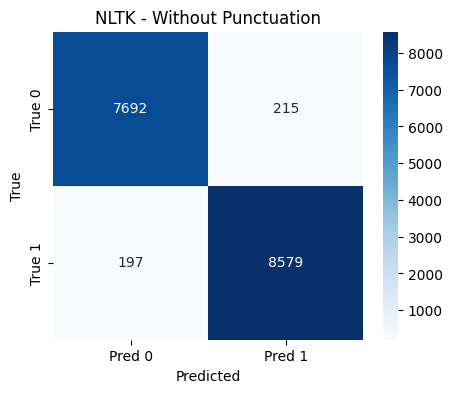

In [37]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("NLTK - Without Punctuation")
plt.xlabel("Predicted")
plt.ylabel("True")

# NLTK  с пунктуацией

In [38]:
tokenized_nltk_with_punct = []
for text in tqdm(df["text"], desc="NLTK tokenizing (with punct)"):
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w not in stop or w in string.punctuation]
    tokenized_nltk_with_punct.append(tokens)

NLTK tokenizing (with punct): 100%|██████████| 83448/83448 [02:26<00:00, 567.99it/s]


In [39]:
mask = [len(x) > 0 for x in tokenized_nltk_with_punct]
X_nltk_with_p = [x for i, x in enumerate(tokenized_nltk_with_punct) if mask[i]]
y_nltk = df["label"].values[mask]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_nltk_with_p, y_nltk, test_size=0.2, random_state=42, stratify=y_nltk
)

In [41]:
w2v = Word2Vec(vector_size=200, window=7, sg=1, min_count=2, seed=42, workers=8, compute_loss=True)
w2v.build_vocab(X_train)

prev_total_loss = 0.0
pbar = tqdm(range(EPOCHS), desc="Word2Vec epochs", unit="epoch")

with suppress_stderr():
    for epoch in pbar:
        w2v.train(X_train, total_examples=w2v.corpus_count, epochs=1)
        total_loss = w2v.get_latest_training_loss()
        epoch_loss = total_loss - prev_total_loss
        prev_total_loss = total_loss
        pbar.set_postfix(loss=f"{epoch_loss:.2f}", vocab=len(w2v.wv))

Word2Vec epochs: 100%|██████████| 10/10 [05:41<00:00, 34.11s/epoch, loss=0.00, vocab=141247]


In [42]:
X_train_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_train])
X_test_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_test])

In [43]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

In [44]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

Vocab size: 141247
Accuracy: 0.9774
              precision    recall  f1-score   support

           0     0.9771    0.9752    0.9761      7908
           1     0.9777    0.9794    0.9786      8781

    accuracy                         0.9774     16689
   macro avg     0.9774    0.9773    0.9773     16689
weighted avg     0.9774    0.9774    0.9774     16689



Vocab size: 141247
Accuracy: 0.9774
              precision    recall  f1-score   support

           0     0.9771    0.9752    0.9761      7908
           1     0.9777    0.9794    0.9786      8781

    accuracy                         0.9774     16689
   macro avg     0.9774    0.9773    0.9773     16689
weighted avg     0.9774    0.9774    0.9774     16689



Text(33.22222222222222, 0.5, 'True')

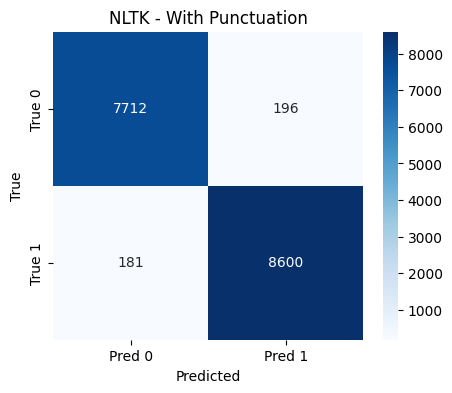

In [45]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("NLTK - With Punctuation")
plt.xlabel("Predicted")
plt.ylabel("True")

# Таблица NLTK

| Библиотека | Подход | Vocab Size | Accuracy |
|------------|--------|------------|----------|
| NLTK | Без пунктуации | 138,733 | 0.9753 |
| NLTK | С пунктуацией | 141,247 | 0.9774 |


# Spacy без пунктуации

In [49]:
nlp = spacy.blank("en")
stop_spacy = nlp.Defaults.stop_words

In [50]:
tokenized_spacy_no_punct = []
for doc in tqdm(nlp.pipe(df["text"], batch_size=2000), total=len(df), desc="spaCy (no punct)"):
    tokens = [t.text.lower() for t in doc 
              if not t.is_punct and t.is_alpha and len(t) > 2 and t.text.lower() not in stop_spacy]
    tokenized_spacy_no_punct.append(tokens)

spaCy (no punct): 100%|██████████| 83448/83448 [02:03<00:00, 675.36it/s]


In [51]:

mask = [len(x) > 0 for x in tokenized_spacy_no_punct]
X_spacy_no_p = [x for i, x in enumerate(tokenized_spacy_no_punct) if mask[i]]
y_spacy = df["label"].values[mask]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_spacy_no_p, y_spacy, test_size=0.2, random_state=42, stratify=y_spacy
)

In [53]:
w2v = Word2Vec(vector_size=200, window=7, sg=1, min_count=2, seed=42, workers=8, compute_loss=True)
w2v.build_vocab(X_train)

prev_total_loss = 0.0
pbar = tqdm(range(EPOCHS), desc="Word2Vec epochs", unit="epoch")

with suppress_stderr():
    for epoch in pbar:
        w2v.train(X_train, total_examples=w2v.corpus_count, epochs=1)
        total_loss = w2v.get_latest_training_loss()
        epoch_loss = total_loss - prev_total_loss
        prev_total_loss = total_loss
        pbar.set_postfix(loss=f"{epoch_loss:.2f}", vocab=len(w2v.wv))


Word2Vec epochs: 100%|██████████| 10/10 [04:18<00:00, 25.87s/epoch, loss=0.00, vocab=125524]


In [54]:
X_train_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_train])
X_test_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_test])

In [55]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

In [56]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))


Vocab size: 125524
Accuracy: 0.9769
              precision    recall  f1-score   support

           0     0.9761    0.9752    0.9756      7905
           1     0.9777    0.9785    0.9781      8772

    accuracy                         0.9769     16677
   macro avg     0.9769    0.9768    0.9769     16677
weighted avg     0.9769    0.9769    0.9769     16677



Text(33.22222222222222, 0.5, 'True')

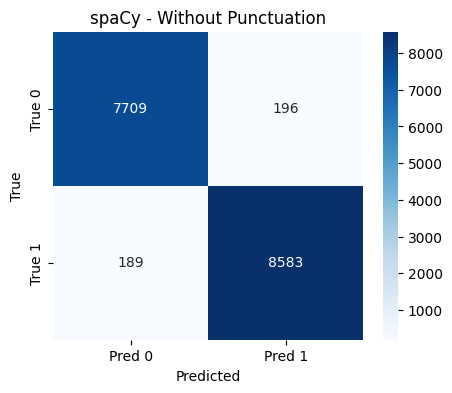

In [57]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("spaCy - Without Punctuation")
plt.xlabel("Predicted")
plt.ylabel("True")

# Spacy с пунктуацией

In [59]:

tokenized_spacy_with_punct = []
for doc in tqdm(nlp.pipe(df["text"], batch_size=2000), total=len(df), desc="spaCy (with punct)"):
    tokens = [t.text.lower() for t in doc 
              if (t.is_punct or (t.is_alpha and len(t) > 2 and t.text.lower() not in stop_spacy))]
    tokenized_spacy_with_punct.append(tokens)

spaCy (with punct): 100%|██████████| 83448/83448 [01:46<00:00, 785.80it/s] 


In [60]:
mask = [len(x) > 0 for x in tokenized_spacy_with_punct]
X_spacy_with_p = [x for i, x in enumerate(tokenized_spacy_with_punct) if mask[i]]
y_spacy = df["label"].values[mask]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X_spacy_with_p, y_spacy, test_size=0.2, random_state=42, stratify=y_spacy
)

In [62]:
w2v = Word2Vec(vector_size=200, window=7, sg=1, min_count=2, seed=42, workers=8, compute_loss=True)
w2v.build_vocab(X_train)

prev_total_loss = 0.0
pbar = tqdm(range(EPOCHS), desc="Word2Vec epochs", unit="epoch")

with suppress_stderr():
    for epoch in pbar:
        w2v.train(X_train, total_examples=w2v.corpus_count, epochs=1)
        total_loss = w2v.get_latest_training_loss()
        epoch_loss = total_loss - prev_total_loss
        prev_total_loss = total_loss
        pbar.set_postfix(loss=f"{epoch_loss:.2f}", vocab=len(w2v.wv))


Word2Vec epochs: 100%|██████████| 10/10 [04:38<00:00, 27.84s/epoch, loss=0.00, vocab=125711]


In [63]:
X_train_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_train])
X_test_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_test])


In [64]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)


In [65]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

Vocab size: 125711
Accuracy: 0.9734
              precision    recall  f1-score   support

           0     0.9729    0.9710    0.9720      7907
           1     0.9740    0.9756    0.9748      8777

    accuracy                         0.9734     16684
   macro avg     0.9734    0.9733    0.9734     16684
weighted avg     0.9734    0.9734    0.9734     16684



Text(33.22222222222222, 0.5, 'True')

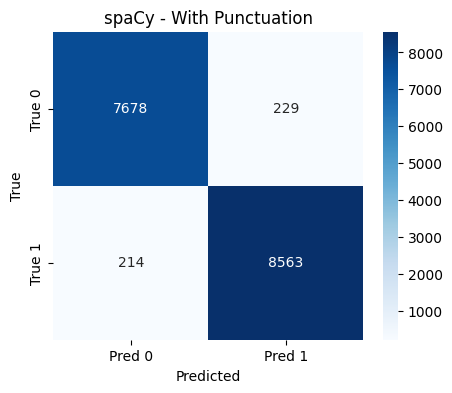

In [66]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("spaCy - With Punctuation")
plt.xlabel("Predicted")
plt.ylabel("True")

# Таблица Spacy

| Библиотека | Подход | Vocab Size | Accuracy |
|------------|--------|------------|----------|
| spaCy | Без пунктуации | 125,524 | 0.9769 |
| spaCy | С пунктуацией | 125,711 | 0.9734 |


# Gensim без пунктуации

In [67]:
tokenized_gensim_no_punct = []
for text in tqdm(df["text"], desc="Gensim (no punct)"):
    tokens = simple_preprocess(text, deacc=True, min_len=3, max_len=30)
    tokens = [w for w in tokens if w not in STOPWORDS]
    tokenized_gensim_no_punct.append(tokens)

Gensim (no punct): 100%|██████████| 83448/83448 [01:01<00:00, 1350.53it/s]


In [68]:

mask = [len(x) > 0 for x in tokenized_gensim_no_punct]
X_gensim_no_p = [x for i, x in enumerate(tokenized_gensim_no_punct) if mask[i]]
y_gensim = df["label"].values[mask]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_gensim_no_p, y_gensim, test_size=0.2, random_state=42, stratify=y_gensim
)

In [70]:
w2v = Word2Vec(vector_size=200, window=7, sg=1, min_count=2, seed=42, workers=8, compute_loss=True)
w2v.build_vocab(X_train)

prev_total_loss = 0.0
pbar = tqdm(range(EPOCHS), desc="Word2Vec epochs", unit="epoch")

with suppress_stderr():
    for epoch in pbar:
        w2v.train(X_train, total_examples=w2v.corpus_count, epochs=1)
        total_loss = w2v.get_latest_training_loss()
        epoch_loss = total_loss - prev_total_loss
        prev_total_loss = total_loss
        pbar.set_postfix(loss=f"{epoch_loss:.2f}", vocab=len(w2v.wv))









Word2Vec epochs: 100%|██████████| 10/10 [04:29<00:00, 26.97s/epoch, loss=0.00, vocab=130678]


In [71]:

X_train_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_train])
X_test_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_test])

In [72]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

In [73]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

Vocab size: 130678
Accuracy: 0.9791
              precision    recall  f1-score   support

           0     0.9792    0.9767    0.9780      7905
           1     0.9791    0.9813    0.9802      8775

    accuracy                         0.9791     16680
   macro avg     0.9791    0.9790    0.9791     16680
weighted avg     0.9791    0.9791    0.9791     16680



Text(33.22222222222222, 0.5, 'True')

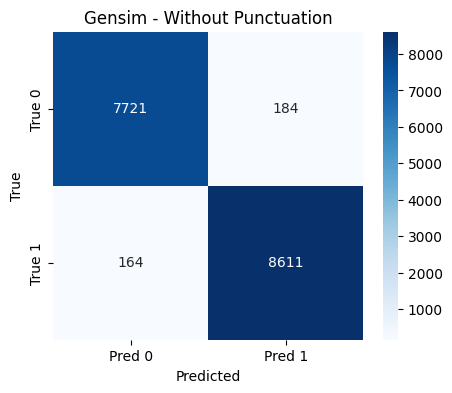

In [74]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Gensim - Without Punctuation")
plt.xlabel("Predicted")
plt.ylabel("True")

# Gensim с пунктуацией

In [75]:
tokenized_gensim_with_punct = []
for text in tqdm(df["text"], desc="Gensim (with punct)"):
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w not in STOPWORDS or w in string.punctuation]
    tokenized_gensim_with_punct.append(tokens)


Gensim (with punct): 100%|██████████| 83448/83448 [02:23<00:00, 580.64it/s]


In [76]:

mask = [len(x) > 0 for x in tokenized_gensim_with_punct]
X_gensim_with_p = [x for i, x in enumerate(tokenized_gensim_with_punct) if mask[i]]
y_gensim = df["label"].values[mask]

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X_gensim_with_p, y_gensim, test_size=0.2, random_state=42, stratify=y_gensim
)


In [78]:
w2v = Word2Vec(vector_size=200, window=7, sg=1, min_count=2, seed=42, workers=8, compute_loss=True)
w2v.build_vocab(X_train)

prev_total_loss = 0.0
pbar = tqdm(range(EPOCHS), desc="Word2Vec epochs", unit="epoch")

with suppress_stderr():
    for epoch in pbar:
        w2v.train(X_train, total_examples=w2v.corpus_count, epochs=1)
        total_loss = w2v.get_latest_training_loss()
        epoch_loss = total_loss - prev_total_loss
        prev_total_loss = total_loss
        pbar.set_postfix(loss=f"{epoch_loss:.2f}", vocab=len(w2v.wv))


Word2Vec epochs: 100%|██████████| 10/10 [05:10<00:00, 31.06s/epoch, loss=0.00, vocab=141208]


In [79]:
X_train_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_train])
X_test_vec = np.vstack([doc_to_vec(doc, w2v) for doc in X_test])

In [80]:

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

In [81]:
print(f"Vocab size: {len(w2v.wv)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

Vocab size: 141208
Accuracy: 0.9769
              precision    recall  f1-score   support

           0     0.9754    0.9760    0.9757      7908
           1     0.9783    0.9778    0.9781      8780

    accuracy                         0.9769     16688
   macro avg     0.9769    0.9769    0.9769     16688
weighted avg     0.9769    0.9769    0.9769     16688



Text(33.22222222222222, 0.5, 'True')

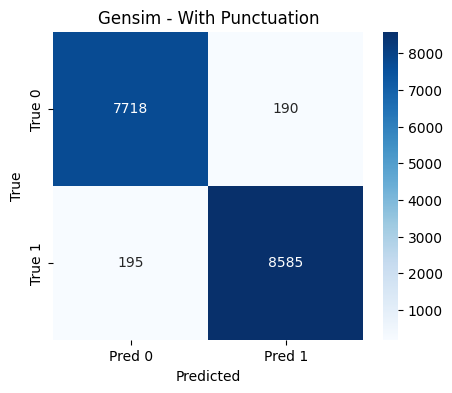

In [82]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Gensim - With Punctuation")
plt.xlabel("Predicted")
plt.ylabel("True")

# Gensim Таблица

| Библиотека | Подход | Vocab Size | Accuracy |
|------------|--------|------------|----------|
| Gensim | Без пунктуации | 130,678 | 0.9791|
| Gensim | С пунктуацией | 141,208 | 0.9769 |

# Финальная таблица сравнения

| Библиотека | Подход | Vocab Size | Accuracy |
|------------|--------|------------|----------|
| NLTK | Без пунктуации | 138,733 | 0.9753 |
| NLTK | С пунктуацией | 141,247 | 0.9774 |
| spaCy | Без пунктуации | 125,524 | 0.9769 |
| spaCy | С пунктуацией | 125,711 | 0.9734 |
| Gensim | Без пунктуации | 130,678 | 0.9791|
| Gensim | С пунктуацией | 141,208 | 0.9769 |
